In [43]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [44]:
data = pd.read_csv('wdbc.csv', header = None)
X = np.array(data.iloc[:, 2:])
y = np.array(data.iloc[:,1])

In [45]:
max_values = [np.max(X[:, j] ) for j in range(len(X[0]))]
X = X *1.0 / max_values

In [46]:
y_binary = []
for i in range(len(y)):
    if y[i] == 'M':
        y_binary.append([1,0])
    else:
        y_binary.append([0,1])
y = np.array(y_binary)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

In [75]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(30,)),
    tf.keras.layers.Dense(100, activation = 'sigmoid'),
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dense(2, activation = 'softmax')
])

In [76]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics = ['precision', 'recall'])

In [77]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 100)            │         3,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,286 (63.62 KB)

 Trainable params: 16,286 (63.62 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
history = model.fit(X_train, y_train, validation_split=0.1, epochs = 20)

Epoch 1/20


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.7069 - precision: 0.5666 - recall: 0.5666 - val_loss: 0.6224 - val_precision: 0.6512 - val_recall: 0.6512
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6508 - precision: 0.7285 - recall: 0.7285 - val_loss: 0.6008 - val_precision: 0.6512 - val_recall: 0.6512
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6185 - precision: 0.6240 - recall: 0.6240 - val_loss: 0.5792 - val_precision: 0.6512 - val_recall: 0.6512
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5904 - precision: 0.6710 - recall: 0.6710 - val_loss: 0.5488 - val_precision: 0.6744 - val_recall: 0.6744
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5586 - precision: 0.6997 - recall: 0.6997 - val_loss: 0.5153 - val_precision: 0.7907 - val_recall: 0.7907
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5250 - precision: 0.7311 - recall: 0.7311 - val_loss: 0.4725 - val_precision: 0.8140 - val_recall: 0.8140
Epoch 7/20
12/

In [79]:
model.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1751 - precision: 0.9441 - recall: 0.9441 


[0.17514456808567047, 0.9440559148788452, 0.9440559148788452]

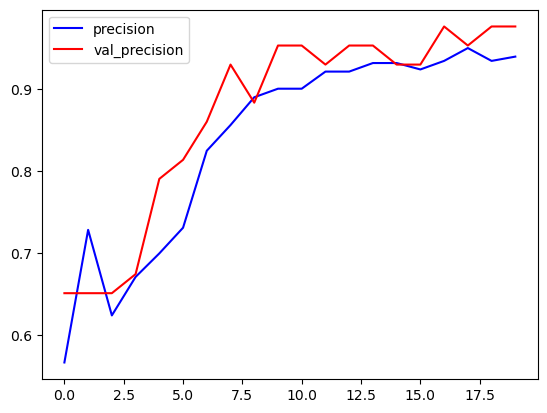

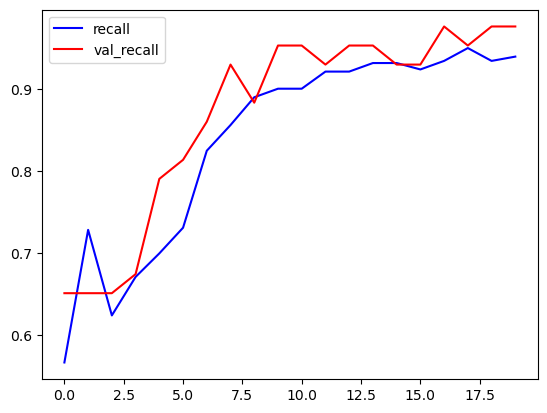

In [80]:
import matplotlib.pyplot as plt

plt.plot(history.history["precision"], color = 'blue', label = 'precision')
plt.plot(history.history['val_precision'], color = 'red', label = 'val_precision')
plt.legend()
plt.show()

plt.plot(history.history["recall"], color = 'blue', label = 'recall')
plt.plot(history.history['val_recall'], color = 'red', label = 'val_recall')
plt.legend()
plt.show()